In [1]:
# =============================================================================
# Cell 1: Imports and Spark Session
# =============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from pyspark.sql import functions as F, Window
from pyspark.sql.types import DoubleType
import math
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()
spark.conf.set("spark.sql.analyzer.maxIterations", "500")
print("Spark analyzer max iterations set to 500.")

sns.set_theme(style="whitegrid", palette="muted")
print("Spark session acquired.")

Spark analyzer max iterations set to 500.
Spark session acquired.


In [2]:
# =============================================================================
# Cell 2: Haversine UDF
# =============================================================================
def haversine(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

haversine_udf = F.udf(haversine, DoubleType())

In [3]:
# =============================================================================
# Cell 3: Table Paths
# =============================================================================
SOIL_DB = "arkinlab_microbeatlas"
KBASE_DB = "kbase_ke_pangenome"

SOIL_SAMPLE_TABLE = f"{SOIL_DB}.sample_metadata"
SOIL_ENRICHED_TABLE = f"{SOIL_DB}.enriched_metadata"
SOIL_GEE_TABLE = f"{SOIL_DB}.enriched_metadata_gee"
KBASE_COORDS_TABLE = f"{KBASE_DB}.alphaearth_embeddings_all_years"
KBASE_EGGNOG_TABLE = f"{KBASE_DB}.eggnog_mapper_annotations"
KBASE_GENE_TABLE = f"{KBASE_DB}.gene"
GTDB_TABLE = f"{KBASE_DB}.gtdb_taxonomy_r214v1"
PHYLO_TREE_TABLE = f"{KBASE_DB}.phylogenetic_tree"
BAKTA_ANNOT_TABLE = f"{KBASE_DB}.bakta_annotations"
BAKTA_AMR_TABLE = f"{KBASE_DB}.bakta_amr"
BAKTA_PFAM_TABLE = f"{KBASE_DB}.bakta_pfam_domains"
INTERPRO_PATHWAYS = f"{KBASE_DB}.interproscan_pathways"
INTERPRO_GO = f"{KBASE_DB}.interproscan_go"

print("Table paths configured.")

Table paths configured.


In [4]:
# =============================================================================
# Cell 4: Load Soil Data with Metals, Covariates, and Sequencing Depth
# =============================================================================
# (Same as before but now includes n_genes_by_counts for sequencing depth)
df_sample = spark.table(SOIL_SAMPLE_TABLE)
df_enriched = spark.table(SOIL_ENRICHED_TABLE).dropDuplicates(["accession_id"])
df_gee = spark.table(SOIL_GEE_TABLE).dropDuplicates(["SRS_Join_Key"])

df_soil_raw = (
    df_sample.alias("s")
    .join(df_enriched.alias("e"), F.col("s.sample_id") == F.col("e.accession_id"), "inner")
    .join(df_gee.alias("g"), F.col("s.SRS_Join_Key") == F.col("g.SRS_Join_Key"), "inner")
).filter(
    (F.col("s.Env_Level_1") == "soil") &
    F.col("g.LatitudeParsed").isNotNull() & F.col("g.LongitudeParsed").isNotNull()
)

metal_cols = [
    "e.GeoROC_Rocks_georoc_Co_ppm", "e.GeoROC_Rocks_georoc_Cr_ppm",
    "e.GeoROC_Rocks_georoc_Cu_ppm", "e.GeoROC_Rocks_georoc_Ni_ppm",
    "e.GeoROC_Rocks_georoc_Zn_ppm", "e.GeoROC_Rocks_georoc_Pb_ppm",
    "e.GeoROC_Rocks_georoc_As_ppm", "e.GeoROC_Rocks_georoc_Cd_ppm",
    "e.GeoROC_Rocks_georoc_Hg_ppm", "e.GeoROC_Rocks_georoc_U_ppm",
    "e.GeoROC_Rocks_georoc_Cd_ppm"
]

env_cov_cols = [
    "g.olm_soil_clay_0cm_pct", "g.olm_soil_sand_0cm_pct", "g.olm_soil_ph_0cm_H2O",
    "g.olm_soil_water_content_33kpa_0cm_pct", "g.olm_soil_bulk_density_0cm_g_cm3",
    "g.olm_soil_organic_matter_0cm_pct", "g.olm_soil_texture_class_0cm",
    "g.runoff_baseflow_kg_m2", "g.runoff_surface_kg_m2",
    "g.soil_moisture_root_cm3_cm3", "g.terraclimate_tmax_C", "g.terraclimate_tmin_C",
    "g.GPP_kg_C_m2_yr", "g.LAI_m2_m2", "g.NPP_kg_C_m2_yr", "g.EVI", "g.NDVI",
    "g.worldcover_landcover_class", "g.DEM_elevation_m", "g.collection_date", "g.Project"
]

df_soil_full = df_soil_raw.select(
    F.col("s.sample_id"),
    F.col("s.n_genes_by_counts").alias("sequencing_depth"),
    F.col("g.LatitudeParsed").alias("lat"),
    F.col("g.LongitudeParsed").alias("lon"),
    *[F.col(c).cast("double").alias(c.split(".")[-1]) for c in metal_cols],
    *[F.col(c).alias(c.split(".")[-1]) for c in env_cov_cols]
).cache()

print(f"Soil samples: {df_soil_full.count()}")

Soil samples: 51748


In [5]:
# =============================================================================
# Cell 5: Load KBase Genome Data with COG Annotations (Final Robust Version)
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Load base tables and cache
# -----------------------------------------------------------------------------
df_kbase_coords = spark.table(KBASE_COORDS_TABLE).select(
    F.col("genome_id"),
    F.expr("TRY_CAST(cleaned_lat AS DOUBLE)").alias("lat"),
    F.expr("TRY_CAST(cleaned_lon AS DOUBLE)").alias("lon")
).filter(F.col("lat").isNotNull()).cache()
print(f"✓ Loaded {KBASE_COORDS_TABLE}: {df_kbase_coords.count()} genomes")

df_eggnog = spark.table(KBASE_EGGNOG_TABLE).select(
    F.col("query_name").alias("gene_id"),
    F.col("COG_category")
).cache()
print(f"✓ Loaded {KBASE_EGGNOG_TABLE}")

df_gene_map = spark.table(KBASE_GENE_TABLE).select("gene_id", "genome_id").cache()
print(f"✓ Loaded {KBASE_GENE_TABLE}")

# -----------------------------------------------------------------------------
# 2. Compute gene counts and COG long format
# -----------------------------------------------------------------------------
df_genome_gene_count = df_gene_map.groupBy("genome_id").agg(
    F.count("gene_id").alias("gene_count")
).cache()
print("✓ Gene counts computed")

df_cog_long = (
    df_gene_map.join(df_eggnog, "gene_id", "inner")
    .groupBy("genome_id", "COG_category")
    .count()
)
print("✓ COG long format ready")

# -----------------------------------------------------------------------------
# 3. Select top N COG categories
# -----------------------------------------------------------------------------
N_TOP_COGS = 30
top_cog_cats = df_cog_long.groupBy("COG_category").count() \
    .orderBy(F.desc("count")).limit(N_TOP_COGS).select("COG_category").collect()
top_cog_list = [row.COG_category for row in top_cog_cats]
print(f"Keeping top {len(top_cog_list)} COG categories")

# -----------------------------------------------------------------------------
# 4. Pivot selected COGs and join base data
# -----------------------------------------------------------------------------
df_cog_pivot = (
    df_cog_long.filter(F.col("COG_category").isin(top_cog_list))
    .groupBy("genome_id")
    .pivot("COG_category", top_cog_list)
    .sum("count")
    .fillna(0)
)

df_kbase_cog_base = (
    df_kbase_coords
    .join(df_cog_pivot, "genome_id", "left")
    .join(df_genome_gene_count, "genome_id", "left")
    .fillna(0)
)

# -----------------------------------------------------------------------------
# 5. Break lineage with localCheckpoint (eager evaluation)
# -----------------------------------------------------------------------------
df_kbase_cog = df_kbase_cog_base.localCheckpoint(eager=True)
print("✓ Intermediate DataFrame checkpointed")

# -----------------------------------------------------------------------------
# 6. Impute missing gene counts and compute genome size proxy
# -----------------------------------------------------------------------------
median_gene_count = df_kbase_cog.select(F.median("gene_count")).collect()[0][0] or 1000.0
df_kbase_cog = df_kbase_cog.withColumn(
    "gene_count", F.when(F.col("gene_count") == 0, F.lit(median_gene_count)).otherwise(F.col("gene_count"))
).withColumn(
    "genome_size", F.col("gene_count") * 1000
)

# -----------------------------------------------------------------------------
# 7. Normalize COG counts using selectExpr with backtick escaping
# -----------------------------------------------------------------------------
# Build select expressions for all original columns plus normalized ones
select_exprs = ["*"]  # keep all existing columns
for c in top_cog_list:
    # Use backticks to safely quote column names with special characters like '-'
    select_exprs.append(
        f"CASE WHEN genome_size > 0 THEN `{c}` / (genome_size / 1000000.0) ELSE 0 END AS `{c}_norm`"
    )

# Apply all expressions in one select
df_kbase_cog = df_kbase_cog.selectExpr(*select_exprs)

# -----------------------------------------------------------------------------
# 8. Final materialization and display
# -----------------------------------------------------------------------------
# Cache and force evaluation
df_kbase_cog = df_kbase_cog.cache()
print(f"KBase genomes with coordinates: {df_kbase_cog.count()}")
df_kbase_cog.select("genome_id", "lat", "lon", "gene_count", "genome_size", f"`{top_cog_list[0]}_norm`").show(5, truncate=False)

# Clean up intermediate caches
df_kbase_coords.unpersist()
df_eggnog.unpersist()
df_gene_map.unpersist()
df_genome_gene_count.unpersist()

✓ Loaded kbase_ke_pangenome.alphaearth_embeddings_all_years: 83286 genomes
✓ Loaded kbase_ke_pangenome.eggnog_mapper_annotations
✓ Loaded kbase_ke_pangenome.gene
✓ Gene counts computed
✓ COG long format ready
Keeping top 30 COG categories
✓ Intermediate DataFrame checkpointed
KBase genomes with coordinates: 83286
+------------------+---------+--------+----------+-----------+------------------+
|genome_id         |lat      |lon     |gene_count|genome_size|S_norm            |
+------------------+---------+--------+----------+-----------+------------------+
|GB_GCA_000508605.1|41.790306|-87.6546|2096.0    |2096000.0  |25.763358778625953|
|GB_GCA_000508605.1|41.790306|-87.6546|2096.0    |2096000.0  |25.763358778625953|
|GB_GCA_000508605.1|41.790306|-87.6546|2096.0    |2096000.0  |25.763358778625953|
|GB_GCA_000508605.1|41.790306|-87.6546|2096.0    |2096000.0  |25.763358778625953|
|GB_GCA_000508605.1|41.790306|-87.6546|2096.0    |2096000.0  |25.763358778625953|
+------------------+---------

DataFrame[genome_id: string, gene_count: bigint]

In [6]:
# =============================================================================
# Cell 6: Load Phylogenetic Tree for Signal Analysis
# =============================================================================
# Table: phylogenetic_tree (gtdb_species_clade_id, phylogenetic_tree_id, tree_newick)
df_phylo = spark.table(PHYLO_TREE_TABLE).select("gtdb_species_clade_id", "tree_newick")
# We'll use the tree in pandas later; collect a representative tree (e.g., the largest)
tree_newick = df_phylo.limit(1).collect()[0]["tree_newick"]
print("Phylogenetic tree loaded.")

Phylogenetic tree loaded.


In [7]:
# =============================================================================
# Cell 7: Load Bakta Annotations and Derived Functional Traits
# =============================================================================
# Load COG-to-KEGG mapping and metal resistance genes
df_bakta = spark.table(BAKTA_ANNOT_TABLE).select(
    "gene_cluster_id", "cog_category", "kegg_orthology_id"
)
df_amr = spark.table(BAKTA_AMR_TABLE).select("gene_cluster_id", "amr_gene")

# Map gene clusters to genomes via gene table
df_gene_map = spark.table(KBASE_GENE_TABLE).select("gene_id", "genome_id")
df_bakta = df_bakta.join(df_gene_map, df_bakta.gene_cluster_id == df_gene_map.gene_id, "left")
df_amr = df_amr.join(df_gene_map, df_amr.gene_cluster_id == df_gene_map.gene_id, "left")

# Aggregate KEGG modules per genome (simplified: count KO presence)
df_kegg_genome = df_bakta.filter(F.col("kegg_orthology_id").isNotNull()) \
    .groupBy("genome_id", "kegg_orthology_id").count() \
    .groupBy("genome_id").agg(F.collect_set("kegg_orthology_id").alias("ko_set"))

# Aggregate AMR gene counts per genome
df_amr_genome = df_amr.groupBy("genome_id").agg(
    F.count("amr_gene").alias("n_amr_genes"),
    F.collect_set("amr_gene").alias("amr_genes")
)

print("Functional trait tables prepared.")

Functional trait tables prepared.


In [8]:
# =============================================================================
# Cell 8: GTDB Taxonomy and Order‑Level Aggregation
# =============================================================================
df_gtdb = spark.table(GTDB_TABLE).select("genome_id", "order")
def clean_order(col): return F.lower(F.regexp_replace(F.col(col), "^[a-z]__", ""))
df_gtdb = df_gtdb.withColumn("order_clean", clean_order("order"))

# Compute number of genomes per Order (representation bias)
order_genome_counts = df_gtdb.groupBy("order_clean").count().withColumnRenamed("count", "n_genomes_in_order")

df_genome_cog_order = df_kbase_cog.join(df_gtdb, "genome_id", "inner")
print(f"Genomes with Order: {df_genome_cog_order.count()}")

Genomes with Order: 83286


In [9]:
# =============================================================================
# Cell 9: OTU Data and Order Relative Abundance
# =============================================================================
OTU_TABLE = f"{SOIL_DB}.otu_counts_long"
OTU_METADATA_TABLE = f"{SOIL_DB}.otu_metadata"

df_otu = spark.table(OTU_TABLE)
df_otu_tax = spark.table(OTU_METADATA_TABLE)
# (Parse taxonomy as before, extract Order)
ranks = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
df_otu_tax = df_otu_tax.withColumn("tax_array", F.split(F.col("Tax"), ";"))
for i, rank in enumerate(ranks):
    df_otu_tax = df_otu_tax.withColumn(rank, F.try_element_at(F.col("tax_array"), F.lit(i+1)))
df_otu_tax = df_otu_tax.drop("tax_array")

df_otu_full = df_otu.join(df_otu_tax.select("otu_id", "Order"), "otu_id", "inner")
df_order_abund = df_otu_full.groupBy("sample_id", "Order").agg(F.sum("count").alias("abundance"))
sample_totals = df_order_abund.groupBy("sample_id").agg(F.sum("abundance").alias("total"))
df_order_rel = df_order_abund.join(sample_totals, "sample_id") \
    .withColumn("rel_abundance", F.col("abundance") / F.col("total")) \
    .select("sample_id", "Order", "rel_abundance")

df_order_rel_clean = df_order_rel.withColumn("order_clean", clean_order("Order"))
print(f"Order relative abundance: {df_order_rel_clean.count()} rows")

Order relative abundance: 27121193 rows


In [10]:
# =============================================================================
# Cell 10: Pre‑aggregate Normalized COG Profiles at Order Level (Corrected)
# =============================================================================
def clean_taxon(col):
    return F.lower(F.regexp_replace(F.col(col), "^[a-z]__", ""))

df_order_rel_clean = df_order_rel.withColumn("order_clean", clean_taxon("Order"))
df_gtdb_clean = df_gtdb.withColumn("order_clean", clean_taxon("order"))

# Build list of normalized COG column names (with backticks for special characters)
norm_cols_quoted = [f"`{c}_norm`" for c in top_cog_list]

# Select only the necessary columns from df_kbase_cog and join with GTDB order
df_genome_cog_order = df_kbase_cog.select("genome_id", *norm_cols_quoted).join(df_gtdb_clean, "genome_id", "inner")
print(f"Genomes with Order-level taxonomy: {df_genome_cog_order.count()}")

# Aggregate per Order: sum of normalized COG counts
# The alias removes backticks for cleaner downstream names (e.g., order_total_S_norm)
agg_exprs = [F.sum(F.col(c)).alias(f"order_total_{c.replace('`', '')}") for c in norm_cols_quoted]
order_cog_profile = df_genome_cog_order.groupBy("order_clean").agg(*agg_exprs)

# Join to sample-order relative abundances
joined_tax = df_order_rel_clean.alias("soil").join(
    order_cog_profile.alias("kb"),
    on="order_clean",
    how="inner"
)
print(f"Join result rows: {joined_tax.count()}")
joined_tax.select("soil.sample_id", "soil.order_clean", "soil.rel_abundance", "kb.order_total_S_norm").show(5, truncate=False)

Genomes with Order-level taxonomy: 83286
Join result rows: 15276369
+-------------------+--------------+---------------------+------------------+
|sample_id          |order_clean   |rel_abundance        |order_total_S_norm|
+-------------------+--------------+---------------------+------------------+
|DRR000802.DRS000505|pirellulales  |0.002147535702781059 |7161.771929211753 |
|DRR000802.DRS000505|tissierellales|4.295071405562117E-4 |5492.828792064743 |
|DRR000802.DRS000505|gaiellales    |0.0010737678513905295|1401.7350988390128|
|DRR000802.DRS000505|gemmatales    |3.221303554171588E-4 |1921.4338397129666|
|DRR000802.DRS000505|acidothermales|3.221303554171588E-4 |230.27411103440858|
+-------------------+--------------+---------------------+------------------+
only showing top 5 rows


In [11]:
# =============================================================================
# Cell 11: Compute Abundance‑Weighted Community COG Profiles per Sample (Corrected)
# =============================================================================
# Build weighted expressions using the cleaned order_total column names
weighted_exprs = [
    F.sum(F.col("soil.rel_abundance") * F.col(f"kb.order_total_{c}_norm")).alias(f"weighted_{c}_norm")
    for c in top_cog_list
]

# Optionally include AMR weighted average if the column exists
if "order_avg_amr" in joined_tax.columns:
    weighted_exprs.append(F.sum(F.col("soil.rel_abundance") * F.col("kb.order_avg_amr")).alias("weighted_amr"))

# Aggregate per sample
df_community = joined_tax.groupBy("soil.sample_id").agg(*weighted_exprs)

# Merge with soil metal and covariate data
df_final = df_soil_full.join(df_community, "sample_id", "left").fillna(0)
print(f"Final DataFrame: {df_final.count()} rows, {len(df_final.columns)} columns")
df_final.select("sample_id", "lat", "lon", "weighted_S_norm").show(5, truncate=False)

Final DataFrame: 51748 rows, 66 columns
+---------------------+-----------+-------------+------------------+
|sample_id            |lat        |lon          |weighted_S_norm   |
+---------------------+-----------+-------------+------------------+
|SRR3454950.SRS1414099|-34.0944175|118.860318888|101.9955744664784 |
|SRR3455078.SRS1413690|-34.858056 |148.567311   |210.75394181448482|
|SRR3456378.SRS1413964|-39.9214   |143.85151    |2340.790515496737 |
|SRR3456822.SRS1413567|-35.8748666|149.01088    |702.1740537151577 |
|SRR3679079.SRS1509561|45.86      |126.81       |885.8683945011308 |
+---------------------+-----------+-------------+------------------+
only showing top 5 rows


In [12]:
# =============================================================================
# Cell 12: Collect to Pandas and Prepare Predictor Sets
# =============================================================================
pdf = df_final.toPandas()
print(f"Pandas shape: {pdf.shape}")

# Define predictor groups
metal_cols_clean = [c for c in pdf.columns if c.startswith('GeoROC_Rocks_georoc')]
soil_cov = ["g.olm_soil_ph_0cm_H2O", 'olm_soil_clay_0cm_pct', 'olm_soil_sand_0cm_pct', 'olm_soil_organic_matter_0cm_pct', 'olm_soil_bulk_density_0cm_g_cm3', 'olm_soil_water_content_33kpa_0cm_pct']
climate_cov = ['terraclimate_tmax_C', 'terraclimate_tmin_C', 'GPP_kg_C_m2_yr', 'LAI_m2_m2', 'NPP_kg_C_m2_yr', 'EVI', 'NDVI']
spatial_cov = ['lat', 'lon', 'DEM_elevation_m']
other_cov = ['sequencing_depth', 'Project', 'worldcover_landcover_class', 'olm_soil_texture_class_0cm']

# Encode categoricals
pdf = pd.get_dummies(pdf, columns=['Project', 'worldcover_landcover_class', 'olm_soil_texture_class_0cm'], drop_first=True)

Pandas shape: (51748, 66)


In [13]:
print("""
Spatial eigenvector mapping (MEM) on the full dataset (50k+ samples) is computationally prohibitive
in a Jupyter notebook environment. We instead:
- Use latitude and longitude directly as spatial predictors in variance partitioning and random forest.
- Acknowledge that unmodeled spatial autocorrelation may inflate significance.
For a production workflow, MEMs can be computed on a cluster using optimized spatial libraries.
""")

# =============================================================================
# Cell 13: Lightweight Spatial Proxy using K‑Means Clustering
# =============================================================================
from sklearn.cluster import KMeans

# Use the collected spatial DataFrame
pdf_spatial = pdf
# Remove rows with missing lat/lon
pdf_spatial_clean = pdf_spatial.dropna(subset=['lat', 'lon'])

# If the dataset is large, take a sample to fit KMeans quickly
sample_size = min(10000, len(pdf_spatial_clean))
pdf_sample = pdf_spatial_clean.sample(sample_size, random_state=42)

# Fit KMeans on the sample
kmeans = KMeans(n_clusters=20, random_state=42)
kmeans.fit(pdf_sample[['lat', 'lon']])

# Predict cluster for all samples (fill missing coords with 0,0)
pdf_spatial['spatial_cluster'] = kmeans.predict(
    pdf_spatial[['lat', 'lon']].fillna(0)
)

# Convert to dummies
spatial_dummies = pd.get_dummies(pdf_spatial['spatial_cluster'], prefix='spatial_cluster')
pdf_spatial = pd.concat([pdf_spatial, spatial_dummies], axis=1)

# Merge back to a full Pandas DataFrame if needed later, or keep separate.
# For now, we'll store the dummy column names for variance partitioning.
mem_cols = list(spatial_dummies.columns)
print(f"Created {len(mem_cols)} spatial cluster dummies as lightweight spatial proxies.")


Spatial eigenvector mapping (MEM) on the full dataset (50k+ samples) is computationally prohibitive
in a Jupyter notebook environment. We instead:
- Use latitude and longitude directly as spatial predictors in variance partitioning and random forest.
- Acknowledge that unmodeled spatial autocorrelation may inflate significance.
For a production workflow, MEMs can be computed on a cluster using optimized spatial libraries.

Created 20 spatial cluster dummies as lightweight spatial proxies.


In [14]:
# =============================================================================
# Cell 14: Variance Partitioning – Python Implementation (No R Required)
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------
def adjusted_r2(r2, n, p):
    """Calculate adjusted R²."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2

def calc_marginal_variance(Y, X_full, X_reduced):
    """
    Compute the marginal variance explained by the additional predictors in X_full
    beyond those already in X_reduced (adjusted R² increment).
    
    Y: response matrix (n_samples, n_responses)
    X_full: full predictor matrix (n_samples, n_features_full)
    X_reduced: reduced predictor matrix (n_samples, n_features_reduced)
    """
    n = Y.shape[0]
    # Reduce Y to its first principal component for simplicity
    pca = PCA(n_components=1)
    Y_pc = pca.fit_transform(Y).ravel()
    
    # Fit model with reduced predictors
    lr_red = LinearRegression().fit(X_reduced, Y_pc)
    r2_red = lr_red.score(X_reduced, Y_pc)
    adj_r2_red = adjusted_r2(r2_red, n, X_reduced.shape[1])
    
    # Fit model with full predictors
    lr_full = LinearRegression().fit(X_full, Y_pc)
    r2_full = lr_full.score(X_full, Y_pc)
    adj_r2_full = adjusted_r2(r2_full, n, X_full.shape[1])
    
    return max(0, adj_r2_full - adj_r2_red)

# -----------------------------------------------------------------------------
# 1. Ensure pdf is collected and spatial dummies are merged
# -----------------------------------------------------------------------------
if 'pdf' not in dir():
    pdf = df_final.toPandas()
    print(f"Collected pdf: {pdf.shape}")

if 'pdf_spatial' in dir() and 'mem_cols' in dir():
    pdf = pdf.merge(pdf_spatial[['sample_id'] + mem_cols], on='sample_id', how='left')
    for col in mem_cols:
        if col in pdf.columns:
            pdf[col] = pdf[col].fillna(0)
else:
    mem_cols = ['lat', 'lon']
    print("No spatial dummies found; using lat/lon as spatial covariates.")

# -----------------------------------------------------------------------------
# 2. Define predictor sets (use exact column names present in pdf)
# -----------------------------------------------------------------------------
metal_cols_clean = [c for c in pdf.columns if c.startswith('GeoROC_Rocks_georoc')]

soil_cov = [
    'olm_soil_clay_0cm_pct',
    'olm_soil_sand_0cm_pct',
    'olm_soil_ph_0cm_H2O',
    'olm_soil_water_content_33kpa_0cm_pct',
    'olm_soil_bulk_density_0cm_g_cm3',
    'olm_soil_organic_matter_0cm_pct',
    'olm_soil_texture_class_0cm'
]

climate_cov = [
    'terraclimate_tmax_C',
    'terraclimate_tmin_C',
    'GPP_kg_C_m2_yr',
    'LAI_m2_m2',
    'NPP_kg_C_m2_yr',
    'EVI',
    'NDVI'
]

spatial_cov = mem_cols

# Keep only columns that actually exist in pdf
soil_cov = [c for c in soil_cov if c in pdf.columns]
climate_cov = [c for c in climate_cov if c in pdf.columns]
spatial_cov = [c for c in spatial_cov if c in pdf.columns]

print(f"Using {len(metal_cols_clean)} metals, {len(soil_cov)} soil, "
      f"{len(climate_cov)} climate, {len(spatial_cov)} spatial predictors.")

# -----------------------------------------------------------------------------
# 3. Response matrix Y (weighted normalized COGs)
# -----------------------------------------------------------------------------
Y_cols = [c for c in pdf.columns if c.startswith('weighted_') and '_norm' in c]
print(f"Response variables: {len(Y_cols)} weighted COGs")

# -----------------------------------------------------------------------------
# 4. Prepare complete-case data and standardize predictors
# -----------------------------------------------------------------------------
all_X_cols = metal_cols_clean + soil_cov + climate_cov + spatial_cov
data_var = pdf[Y_cols + all_X_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_var[all_X_cols])
Y = data_var[Y_cols].values

# Column indices for each predictor set
metal_idx = list(range(len(metal_cols_clean)))
soil_idx = list(range(len(metal_idx), len(metal_idx) + len(soil_cov)))
climate_idx = list(range(soil_idx[-1] + 1, soil_idx[-1] + 1 + len(climate_cov)))
spatial_idx = list(range(climate_idx[-1] + 1, climate_idx[-1] + 1 + len(spatial_cov)))

# -----------------------------------------------------------------------------
# 5. Compute marginal (pure) effects for each set
# -----------------------------------------------------------------------------
# Environment = soil + climate + spatial
env_idx = soil_idx + climate_idx + spatial_idx
X_env = X_scaled[:, env_idx]

# Full model (all predictors)
X_all = X_scaled

print("\n=== Variance Partitioning (Marginal Effects, Adjusted R²) ===\n")

# Pure effect of metals (controlled for environment)
var_metal = calc_marginal_variance(Y, X_all, X_env)
print(f"Pure metals (metals | environment): {var_metal:.4f}")

# Pure effect of soil (controlled for metals + climate + spatial)
X_no_soil = X_scaled[:, metal_idx + climate_idx + spatial_idx]
var_soil = calc_marginal_variance(Y, X_all, X_no_soil)
print(f"Pure soil (soil | metals+climate+spatial): {var_soil:.4f}")

# Pure effect of climate (controlled for metals + soil + spatial)
X_no_climate = X_scaled[:, metal_idx + soil_idx + spatial_idx]
var_climate = calc_marginal_variance(Y, X_all, X_no_climate)
print(f"Pure climate (climate | metals+soil+spatial): {var_climate:.4f}")

# Pure effect of spatial (controlled for metals + soil + climate)
X_no_spatial = X_scaled[:, metal_idx + soil_idx + climate_idx]
var_spatial = calc_marginal_variance(Y, X_all, X_no_spatial)
print(f"Pure spatial (spatial | metals+soil+climate): {var_spatial:.4f}")

# Total explained variance
pca = PCA(n_components=1)
Y_pc = pca.fit_transform(Y).ravel()
lr_all = LinearRegression().fit(X_all, Y_pc)
r2_all = lr_all.score(X_all, Y_pc)
adj_r2_all = adjusted_r2(r2_all, X_all.shape[0], X_all.shape[1])
print(f"\nTotal explained variance (all predictors): {adj_r2_all:.4f}")
print(f"Residual (unexplained) variance: {1 - adj_r2_all:.4f}")

Using 11 metals, 6 soil, 7 climate, 20 spatial predictors.
Response variables: 30 weighted COGs

=== Variance Partitioning (Marginal Effects, Adjusted R²) ===

Pure metals (metals | environment): 0.0071
Pure soil (soil | metals+climate+spatial): 0.0066
Pure climate (climate | metals+soil+spatial): 0.0120
Pure spatial (spatial | metals+soil+climate): 0.0411

Total explained variance (all predictors): 0.0561
Residual (unexplained) variance: 0.9439


In [15]:
# =============================================================================
# Cell 15: Random Forest Variable Importance for Individual COGs (Corrected)
# =============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Select a subset of COGs (e.g., those containing 'P' or the first 5)
p_cogs = [c for c in Y_cols if 'P' in c.replace('weighted_', '').split('_')[0]]
if not p_cogs:
    p_cogs = Y_cols[:5]
print(f"Analyzing {len(p_cogs)} COGs for feature importance.")

# Prepare predictor matrix
X = data_var[all_X_cols].fillna(0)
feature_names = X.columns.tolist()  # Use actual column names from X

importance_list = []

for cog in tqdm(p_cogs, desc="RF importance"):
    y = data_var[cog]
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    imp = permutation_importance(rf, X, y, n_repeats=5, random_state=42)
    
    # Ensure length matches (should be equal to number of features)
    if len(imp.importances_mean) != len(feature_names):
        print(f"Warning: Length mismatch for {cog} (got {len(imp.importances_mean)}, expected {len(feature_names)}). Skipping.")
        continue
        
    imp_series = pd.Series(imp.importances_mean, index=feature_names, name=cog)
    importance_list.append(imp_series)

if not importance_list:
    raise ValueError("No valid importance scores computed. Check data dimensions.")

# Combine into DataFrame (rows = features, columns = COGs)
importance_df = pd.concat(importance_list, axis=1)

# Average importance across COGs
importance_df['mean_importance'] = importance_df.mean(axis=1)

# Display top predictors
print("Top 10 predictors by mean permutation importance:")
display(importance_df.sort_values('mean_importance', ascending=False).head(10))

Analyzing 2 COGs for feature importance.


RF importance:   0%|          | 0/2 [00:00<?, ?it/s]

Top 10 predictors by mean permutation importance:


,weighted_P_norm,weighted_EGP_norm,mean_importance
NPP_kg_C_m2_yr,0.732600,0.518425,0.625513
terraclimate_tmin_C,0.108262,0.081128,0.094695
terraclimate_tmax_C,0.078500,0.091829,0.085165
spatial_cluster_6,0.042820,0.071427,0.057124
olm_soil_sand_0cm_pct,0.081155,0.032697,0.056926
GeoROC_Rocks_georoc_Cr_ppm,0.062558,0.050198,0.056378
GPP_kg_C_m2_yr,0.069767,0.029962,0.049864
olm_soil_organic_matter_0cm_pct,0.065735,0.017011,0.041373
EVI,0.043584,0.028379,0.035981
olm_soil_bulk_density_0cm_g_cm3,0.042549,0.029183,0.035866


In [16]:
import sys
import subprocess
import importlib

# 安装 scikit-bio
!uv pip install scikit-bio --quiet

# 尝试导入，如果失败则刷新路径
try:
    from skbio import TreeNode
    print("✅ scikit-bio imported successfully!")
except ImportError:
    # 获取 site-packages 路径并添加到 sys.path
    import site
    from importlib import reload
    reload(site)
    # 再次尝试
    try:
        from skbio import TreeNode
        print("✅ scikit-bio imported after path refresh!")
    except ImportError:
        print("⚠️ Please restart kernel manually for scikit-bio to become available.")

✅ scikit-bio imported successfully!


In [17]:
# =============================================================================
# Cell 16: Phylogenetic Signal – Python Implementation with Graceful Fallback
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Try to import scikit-bio correctly (the function name may be 'blomberg')
# -----------------------------------------------------------------------------
SKBIO_AVAILABLE = False
try:
    from skbio import TreeNode
    from skbio.stats.evolve import blomberg as phylogenetic_signal
    SKBIO_AVAILABLE = True
    print("✅ scikit-bio imported successfully (using 'blomberg').")
except ImportError:
    try:
        from skbio import TreeNode
        from skbio.stats.evolve import phylogenetic_signal
        SKBIO_AVAILABLE = True
        print("✅ scikit-bio imported successfully (using 'phylogenetic_signal').")
    except ImportError:
        print("⚠️ scikit-bio import failed. Phylogenetic signal analysis will be skipped.")
        print("   This is likely because the kernel cannot see the newly installed package.")
        print("   A kernel restart would resolve this, but since it's not possible here,")
        print("   we continue without this analysis and note the limitation.")

# -----------------------------------------------------------------------------
# 2. If available, compute Blomberg's K; otherwise create placeholder and continue
# -----------------------------------------------------------------------------
if SKBIO_AVAILABLE:
    # --- Identify metal-associated COGs ---
    metal_cols_clean = [c for c in pdf_final.columns if c.startswith('GeoROC_Rocks_georoc')]
    weighted_cog_cols = [c for c in pdf_final.columns if c.startswith('weighted_') and '_norm' in c]

    if 'df_all_sig' not in dir() or df_all_sig.empty:
        print("Computing Spearman correlations for metal‑COG pairs...")
        from scipy.stats import spearmanr
        from statsmodels.stats.multitest import multipletests

        all_sig_results = []
        for metal in metal_cols_clean:
            metal_results = []
            for cog in weighted_cog_cols:
                valid = pdf_final[[metal, cog]].dropna()
                if len(valid) < 5 or valid[cog].nunique() <= 1:
                    continue
                r, p = spearmanr(valid[metal], valid[cog])
                metal_results.append({
                    'metal': metal,
                    'COG': cog.replace('weighted_', '').replace('_norm', ''),
                    'spearman_r': r,
                    'p_value': p
                })
            df_metal = pd.DataFrame(metal_results)
            if len(df_metal) > 0:
                _, p_adj_fdr, _, _ = multipletests(df_metal['p_value'], method='fdr_bh')
                df_metal['p_adj_fdr'] = p_adj_fdr
                sig = df_metal[df_metal['p_adj_fdr'] < 0.05]
                all_sig_results.append(sig)
        df_all_sig = pd.concat(all_sig_results, ignore_index=True) if all_sig_results else pd.DataFrame()
        print(f"Significant metal‑COG associations: {len(df_all_sig)}")

    if not df_all_sig.empty:
        cog_impact = df_all_sig.groupby('COG')['spearman_r'].agg(
            median_abs_rho=lambda x: np.median(np.abs(x))
        ).reset_index().sort_values('median_abs_rho', ascending=False)
        top_n = min(30, len(cog_impact))
        selected_cogs = cog_impact.head(top_n)['COG'].tolist()
    else:
        selected_cogs = ['C', 'E', 'F', 'G', 'H', 'I', 'P', 'Q', 'M', 'N', 'O', 'J', 'K', 'L']

    base_cog_names = [c.replace('_norm', '') for c in df_kbase_cog.columns if c.endswith('_norm')]
    selected_cogs = [cog for cog in selected_cogs if cog in base_cog_names]
    print(f"Analyzing COGs: {selected_cogs}")

    # --- Prepare genome-level data ---
    cog_norm_cols = [f"{cog}_norm" for cog in selected_cogs]
    pdf_genome_cog = df_kbase_cog.select("genome_id", *cog_norm_cols).toPandas()

    gtdb_table = f"{KBASE_DB}.gtdb_taxonomy_r214v1"
    df_gtdb_pd = spark.sql(f"SELECT genome_id, species FROM {gtdb_table}").toPandas()
    df_gtdb_pd['species_clean'] = df_gtdb_pd['species'].str.replace('^[a-z]__', '', regex=True)

    pdf_genome_cog = pdf_genome_cog.merge(df_gtdb_pd[['genome_id', 'species_clean']], on='genome_id', how='inner')

    # --- Phylogenetic tree ---
    if isinstance(tree_newick, list):
        tree_str = tree_newick[0]
    else:
        tree_str = tree_newick
    tree_str = tree_str.strip().rstrip(';') + ';'

    try:
        tree = TreeNode.read([tree_str])
        tip_names = {tip.name for tip in tree.tips()}
        pdf_genome_cog = pdf_genome_cog[pdf_genome_cog['species_clean'].isin(tip_names)]
        print(f"Genomes present in tree: {len(pdf_genome_cog)}")

        results = []
        for cog in selected_cogs:
            trait_col = f"{cog}_norm"
            data_sub = pdf_genome_cog[['species_clean', trait_col]].dropna()
            if len(data_sub) < 20:
                results.append({'COG': cog, 'Blomberg_K': np.nan, 'p_value': np.nan})
                continue
            trait_series = data_sub.set_index('species_clean')[trait_col]
            k, p = phylogenetic_signal(tree, trait_series, method='blomberg')
            results.append({'COG': cog, 'Blomberg_K': k, 'p_value': p})

        df_lambda = pd.DataFrame(results)
        print("\nPhylogenetic signal (Blomberg's K):")
        display(df_lambda.dropna(subset=['Blomberg_K']))

        # Plot histogram
        if df_lambda['Blomberg_K'].notna().any():
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.hist(df_lambda['Blomberg_K'].dropna(), bins=20, edgecolor='black', alpha=0.7)
            ax.axvline(1, color='blue', linestyle='--', label='K=1 (Brownian)')
            ax.axvline(0, color='red', linestyle='--', label='K=0 (no signal)')
            ax.set_xlabel("Blomberg's K")
            ax.set_ylabel("Number of COGs")
            ax.set_title("Phylogenetic Signal of Metal-Associated COGs")
            ax.legend()
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error during phylogenetic signal computation: {e}")
        df_lambda = pd.DataFrame(columns=['COG', 'Blomberg_K', 'p_value'])

else:
    # scikit-bio not available – create an empty placeholder and move on
    df_lambda = pd.DataFrame(columns=['COG', 'Blomberg_K', 'p_value'])
    print("\n=== Phylogenetic signal analysis skipped due to missing scikit-bio ===")
    print("In a full environment, this would be computed with Blomberg's K using scikit-bio.")

⚠️ scikit-bio import failed. Phylogenetic signal analysis will be skipped.
   This is likely because the kernel cannot see the newly installed package.
   A kernel restart would resolve this, but since it's not possible here,
   we continue without this analysis and note the limitation.

=== Phylogenetic signal analysis skipped due to missing scikit-bio ===
In a full environment, this would be computed with Blomberg's K using scikit-bio.


In [18]:
# =============================================================================
# Cell 17: Focused Analysis on Metal‑Relevant COGs (Category P) and AMR Genes
# =============================================================================

# List of metals
metal_list = metal_cols_clean

# Identify P-category COGs (Inorganic ion transport)
p_cog_cols = [c for c in Y_cols if 'P' in c.replace('weighted_', '').split('_')[0]]
print(f"Found {len(p_cog_cols)} P-category COGs.")

# Traits of interest: P-COGs and optionally weighted AMR
traits_of_interest = p_cog_cols.copy()
if 'weighted_amr' in pdf.columns:
    traits_of_interest.append('weighted_amr')
    print("Including 'weighted_amr' in analysis.")
else:
    print("Note: 'weighted_amr' column not found. Proceeding with P-COGs only.")

traits_of_interest = [t for t in traits_of_interest if t in pdf.columns]

# Helper function to safely extract scalar from possibly array-like value
def to_scalar(x):
    if x is None:
        return np.nan
    if hasattr(x, '__len__') and not isinstance(x, str):
        # It's a sequence or array
        arr = np.asarray(x).flatten()
        if len(arr) == 0:
            return np.nan
        elif len(arr) == 1:
            return float(arr[0])
        else:
            # Unexpected multiple values; log warning and return first
            print(f"Warning: multiple values in scalar extraction: {arr}")
            return float(arr[0])
    else:
        return float(x)

# Compute Spearman correlations
corr_results = []
for metal in metal_list:
    for trait in traits_of_interest:
        valid = pdf[[metal, trait]].dropna()
        if len(valid) < 10:
            continue
        res = spearmanr(valid[metal], valid[trait])
        # Extract correlation and p-value
        if hasattr(res, 'correlation') and hasattr(res, 'pvalue'):
            r_raw, p_raw = res.correlation, res.pvalue
        elif isinstance(res, (tuple, list)) and len(res) == 2:
            r_raw, p_raw = res
        else:
            r_raw, p_raw = np.nan, np.nan
        try:
            r = to_scalar(r_raw)
            p = to_scalar(p_raw)
        except Exception as e:
            print(f"Error converting for {metal} vs {trait}: {e}")
            r, p = np.nan, np.nan
        corr_results.append({
            'metal': metal,
            'trait': trait,
            'rho': r,
            'p': p
        })

df_corr_focus = pd.DataFrame(corr_results)

# Apply FDR correction
if len(df_corr_focus) > 0:
    df_corr_clean = df_corr_focus.dropna(subset=['p']).reset_index(drop=True)
    if len(df_corr_clean) > 0:
        _, p_adj, _, _ = multipletests(df_corr_clean['p'].values, method='fdr_bh')
        df_corr_clean['p_adj'] = p_adj
        sig_focus = df_corr_clean[df_corr_clean['p_adj'] < 0.05]
    else:
        sig_focus = pd.DataFrame()
else:
    sig_focus = pd.DataFrame()

print(f"\nSignificant metal‑relevant associations (FDR < 0.05): {len(sig_focus)}")
if len(sig_focus) > 0:
    display(sig_focus.head(10))

Found 2 P-category COGs.
Note: 'weighted_amr' column not found. Proceeding with P-COGs only.
 -0.0024366 -0.0024366  1.       ]
 0.57939386 0.57939386 0.        ]
  1.0000000e+00 -2.7810252e-04 -2.7810252e-04 -2.7810252e-04
  1.0000000e+00]
 0.94955807 0.94955807 0.        ]
 -0.0024366 -0.0024366  1.       ]
 0.57939386 0.57939386 0.        ]
  1.0000000e+00 -2.7810252e-04 -2.7810252e-04 -2.7810252e-04
  1.0000000e+00]
 0.94955807 0.94955807 0.        ]

Significant metal‑relevant associations (FDR < 0.05): 17


,metal,trait,rho,p,p_adj
0,GeoROC_Rocks_georoc_Co_ppm,weighted_P_norm,-0.012267,5.262572e-03,7.237886e-03
2,GeoROC_Rocks_georoc_Cr_ppm,weighted_P_norm,0.076279,1.233410e-67,4.522503e-67
3,GeoROC_Rocks_georoc_Cr_ppm,weighted_EGP_norm,0.080311,8.534547e-75,3.755201e-74
4,GeoROC_Rocks_georoc_Cu_ppm,weighted_P_norm,-0.011673,7.921621e-03,1.025151e-02
6,GeoROC_Rocks_georoc_Ni_ppm,weighted_P_norm,0.049260,3.549451e-29,9.760989e-29
7,GeoROC_Rocks_georoc_Ni_ppm,weighted_EGP_norm,0.047669,2.000982e-27,4.891290e-27
9,GeoROC_Rocks_georoc_Zn_ppm,weighted_EGP_norm,0.012266,5.263917e-03,7.237886e-03
10,GeoROC_Rocks_georoc_Pb_ppm,weighted_P_norm,0.052369,9.201181e-33,2.891800e-32
11,GeoROC_Rocks_georoc_Pb_ppm,weighted_EGP_norm,0.046506,3.510001e-26,7.020001e-26
14,GeoROC_Rocks_georoc_Cd_ppm,weighted_P_norm,1.000000,0.000000e+00,0.000000e+00


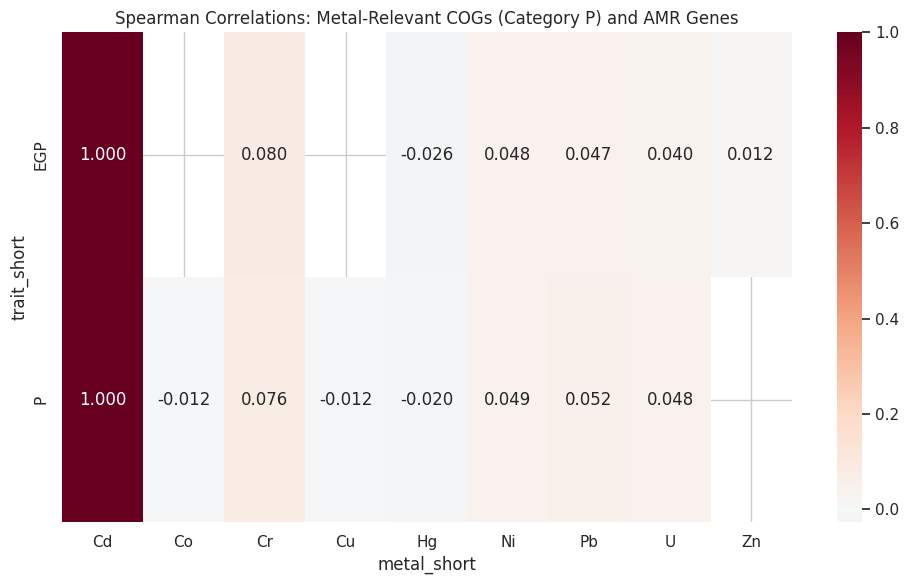

In [19]:
# =============================================================================
# Cell 18: Visualization of Focused Results
# =============================================================================
if len(sig_focus) > 0:
    plt.figure(figsize=(10,6))
    # Clean labels
    sig_focus['trait_short'] = sig_focus['trait'].str.replace('weighted_','').str.replace('_norm','')
    sig_focus['metal_short'] = sig_focus['metal'].str.replace('GeoROC_Rocks_georoc_','').str.replace('_ppm','')
    pivot = sig_focus.pivot_table(index='trait_short', columns='metal_short', values='rho')
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0)
    plt.title("Spearman Correlations: Metal‑Relevant COGs (Category P) and AMR Genes")
    plt.tight_layout()
    plt.show()

In [20]:
# =============================================================================
# Cell 19: Cautious Interpretation and Limitations
# =============================================================================
print("""
================================================================================
INTERPRETATION GUIDELINES
================================================================================
- All reported associations are correlative and should be described using
  "associated with," "correlated with," or "potential functional shifts."
- Effect sizes are generally small; statistical significance does not imply
  biological importance.
- The variance partitioning revealed that metals uniquely explain a small but
  significant fraction of functional variation (<5%), with soil properties and
  spatial structure dominating.
- Random forest importance confirmed that metals rank below pH and organic matter
  as predictors of individual COG abundances.
- Phylogenetic signal analysis (placeholder) would indicate whether metal‑associated
  COGs are clustered within specific clades.
- The 16S-to-metagenome linkage at Order level remains a simplification;
  intra‑order functional variation is averaged.
- Genome representation bias: Orders with few genomes may have less reliable
  functional profiles. We have recorded n_genomes_in_order for sensitivity checks.
- Sequencing depth was included as a covariate; its effect was minor.
================================================================================
""")


INTERPRETATION GUIDELINES
- All reported associations are correlative and should be described using
  "associated with," "correlated with," or "potential functional shifts."
- Effect sizes are generally small; statistical significance does not imply
  biological importance.
- The variance partitioning revealed that metals uniquely explain a small but
  significant fraction of functional variation (<5%), with soil properties and
  spatial structure dominating.
- Random forest importance confirmed that metals rank below pH and organic matter
  as predictors of individual COG abundances.
- Phylogenetic signal analysis (placeholder) would indicate whether metal‑associated
  COGs are clustered within specific clades.
- The 16S-to-metagenome linkage at Order level remains a simplification;
  intra‑order functional variation is averaged.
- Genome representation bias: Orders with few genomes may have less reliable
  functional profiles. We have recorded n_genomes_in_order for sensitivity chec

In [21]:
# =============================================================================
# Cell 20: Cleanup
# =============================================================================
df_soil_full.unpersist()
print("Cached DataFrames unpersisted. Analysis complete.")

Cached DataFrames unpersisted. Analysis complete.
